In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm

In [12]:
beta = 1
ns = [20, 50, 100]
thetas = [0.5, 1, 2, 5]
T = 10**4

In [13]:
import os 

BASE_DIR = '../plots/zad4a'
os.makedirs(BASE_DIR, exist_ok=True)
plot_dist_dir = os.path.join(BASE_DIR, 'wykresy_rozkładow')
os.makedirs(plot_dist_dir, exist_ok=True)
plot_metrics_dir = os.path.join(BASE_DIR, 'wykresy_metryk')
os.makedirs(plot_metrics_dir, exist_ok=True)
stats_dir = os.path.join(BASE_DIR, 'statystyki_metryki')
os.makedirs(stats_dir, exist_ok=True)
print(f"Przygotowano foldery w: {BASE_DIR}")

Przygotowano foldery w: ../plots/zad4a


In [ ]:
def gen_sample(n, theta, beta):
    s = np.random.beta(theta, beta, n)
    return s

In [ ]:
def estimator_theta(xs):
    return -1.0 / np.log(xs).mean()

Wiemy, że dla $X \sim \beta(\theta, 1)$ mamy $\mathbb{E}(X) = \frac{\theta}{\theta+1}$. Więc, po porstych przekształceniach nasz $\hat{\theta}_{MOM} = \frac{\bar{X}}{1-\bar{X}}$.

In [ ]:
def estimator_mom(xs):
    mean_x = xs.mean()
    if mean_x >= 1.0: # Zabezpieczenie przed dzieleniem przez zero
        return np.nan
    return mean_x / (1 - mean_x)

In [17]:
results = {}

metrics = {}

for n in ns:
    results[n] = {}
    metrics[n] = {}
    for theta in thetas:
        mle_ests = []
        mom_ests = []

        for _ in tqdm(range(T), desc=f"n={n}, theta={theta}"):
            sample = gen_sample(n, theta, beta)

            mle_ests.append(estimator_theta(sample))
            mom_ests.append(estimator_mom(sample))

        mle_ests = np.array(mle_ests)
        mom_ests = np.array(mom_ests)

        results[n][theta] = {
            'mle': mle_ests,
            'mom': mom_ests
        }

        mle_clean = mle_ests[~np.isnan(mle_ests)]
        mom_clean = mom_ests[~np.isnan(mom_ests)]

        metrics[n][theta] = {
            'mle': {
                'bias': np.mean(mle_clean) - theta,
                'var': np.var(mle_clean),
                'mse': np.mean((mle_clean - theta)**2)
            },
            'mom': {
                'bias': np.mean(mom_clean) - theta,
                'var': np.var(mom_clean),
                'mse': np.mean((mom_clean - theta)**2)
            }
        }

n=100, theta=5: 100%|██████████| 10000/10000 [00:00<00:00, 118668.54it/s]


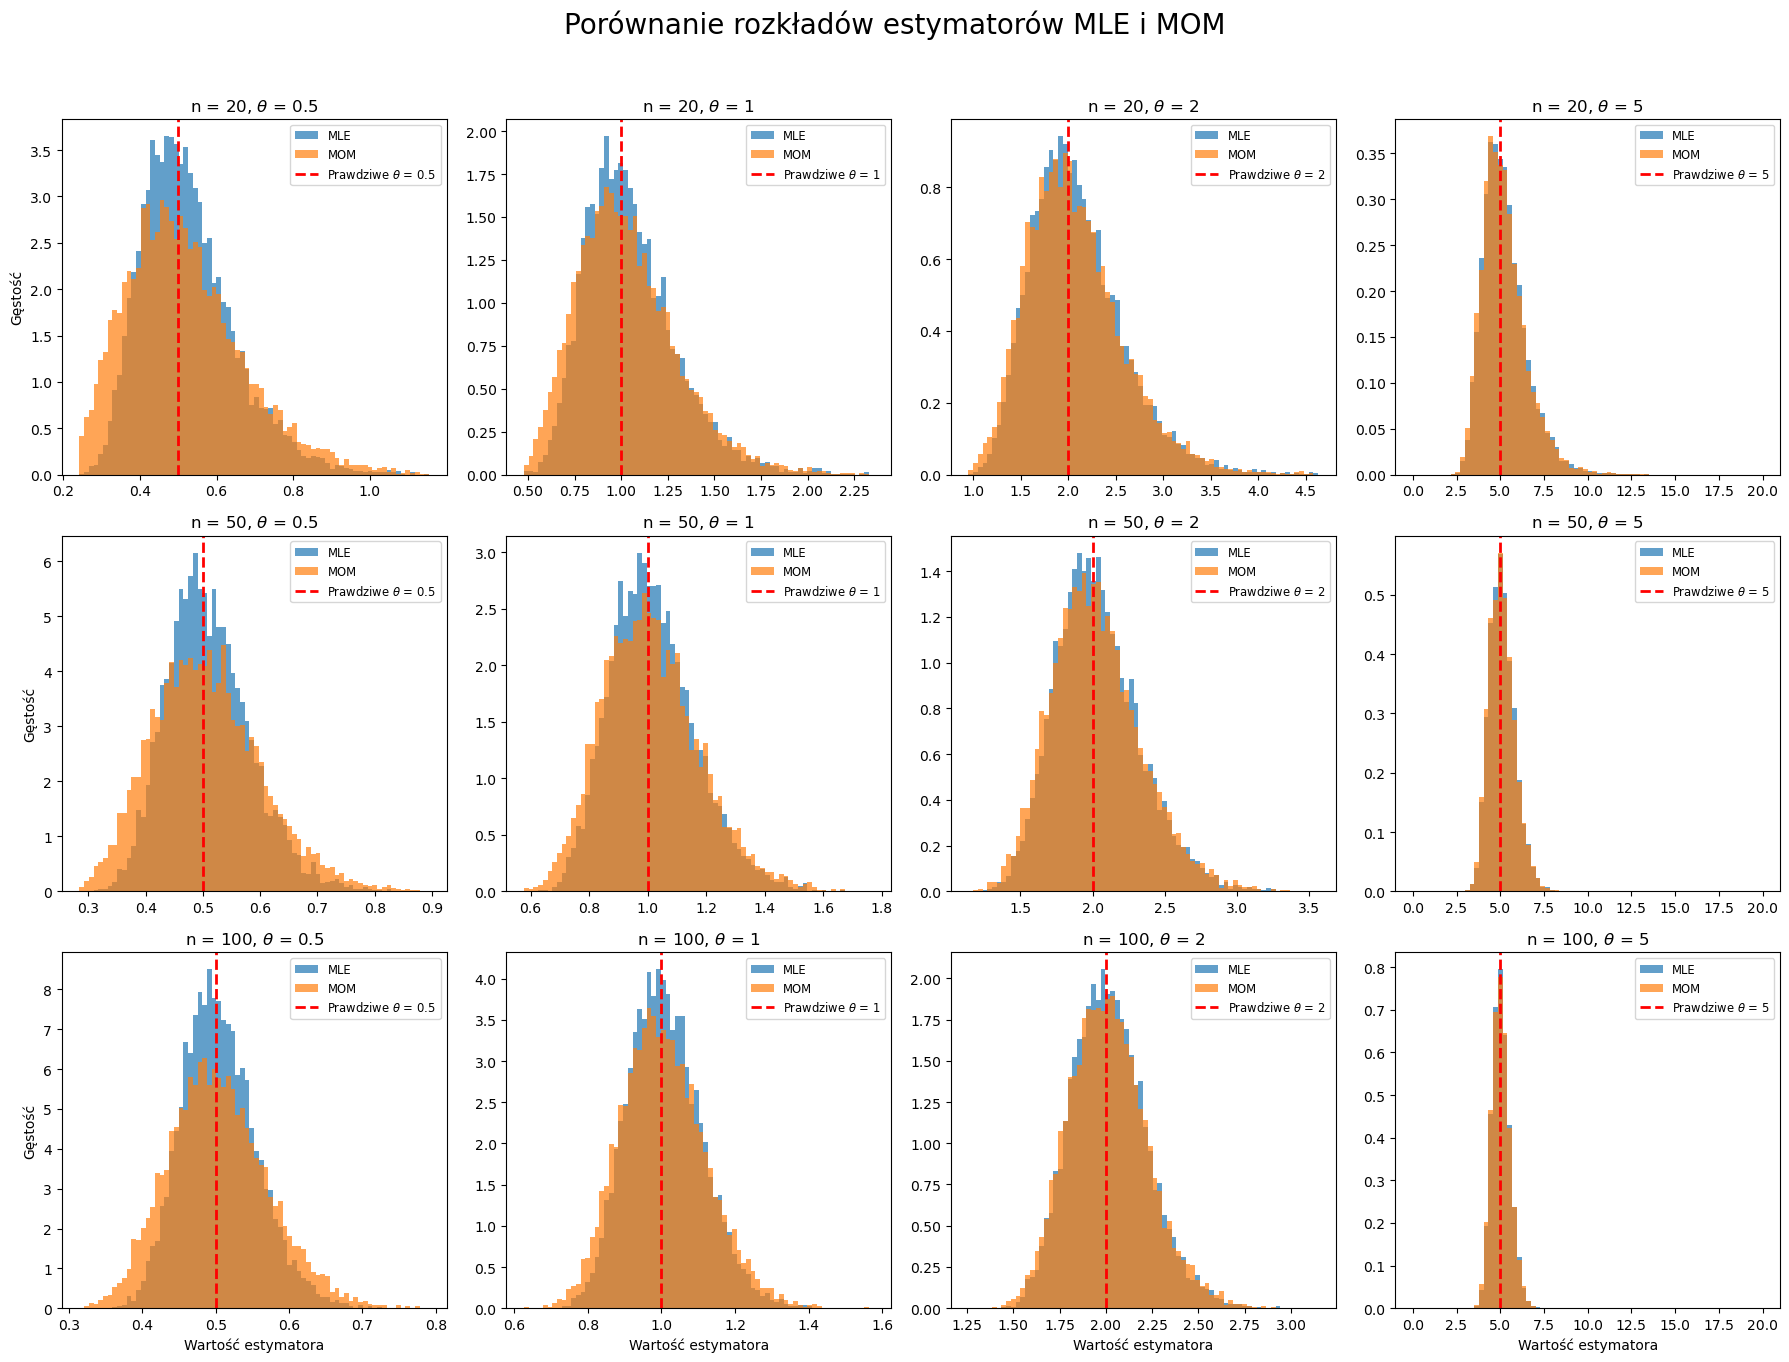

Zapisano wykres rozkładów do: ../plots/zad4a/wykresy_rozkładow/histograms_mle_mom_comparison.png


In [ ]:
fig, axes = plt.subplots(len(ns), len(thetas), figsize=(18, 14), sharex=False)
fig.suptitle('Porównanie rozkładów estymatorów MLE i MOM', fontsize=20, y=1)

for i, n in enumerate(ns):
    for j, theta in enumerate(thetas):
        ax = axes[i, j]
        mle_ests = results[n][theta]['mle']
        mom_ests = results[n][theta]['mom']

        mle_clean = mle_ests[~np.isnan(mle_ests)]
        mom_clean = mom_ests[~np.isnan(mom_ests)]

        # Ograniczenie zakresu dla czytelności (MOM może mieć ekstremalne wartości)
        # Używamy kwantyli MLE jako punktu odniesienia
        q_mle_low = np.percentile(mle_clean, 0.5)
        q_mle_high = np.percentile(mle_clean, 99.5)
        plot_range = (q_mle_low * 0.8, q_mle_high * 1.2)

        # Dla theta=5, MOM eksploduje, więc musimy ręcznie poszerzyć
        if theta == 5:
            plot_range = (0, max(20, q_mle_high * 2))

        bins = np.linspace(plot_range[0], plot_range[1], 75)

        ax.hist(mle_clean, bins=bins, density=True, alpha=0.7, label='MLE')
        ax.hist(mom_clean, bins=bins, density=True, alpha=0.7, label='MOM')

        ax.axvline(theta, color='red', linestyle='--', linewidth=2, label=f'Prawdziwe $\\theta$ = {theta}')

        ax.set_title(f'n = {n}, $\\theta$ = {theta}')
        ax.legend(fontsize='small')
        if i == len(ns) - 1:
            ax.set_xlabel('Wartość estymatora')
        if j == 0:
            ax.set_ylabel('Gęstość')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])

filename = os.path.join(plot_dist_dir, 'histograms_mle_mom_comparison.png')
plt.savefig(filename)

plt.show()
plt.close()
print(f"Zapisano wykres rozkładów do: {filename}")

Generowanie wykresu 2: Metryki vs. theta...


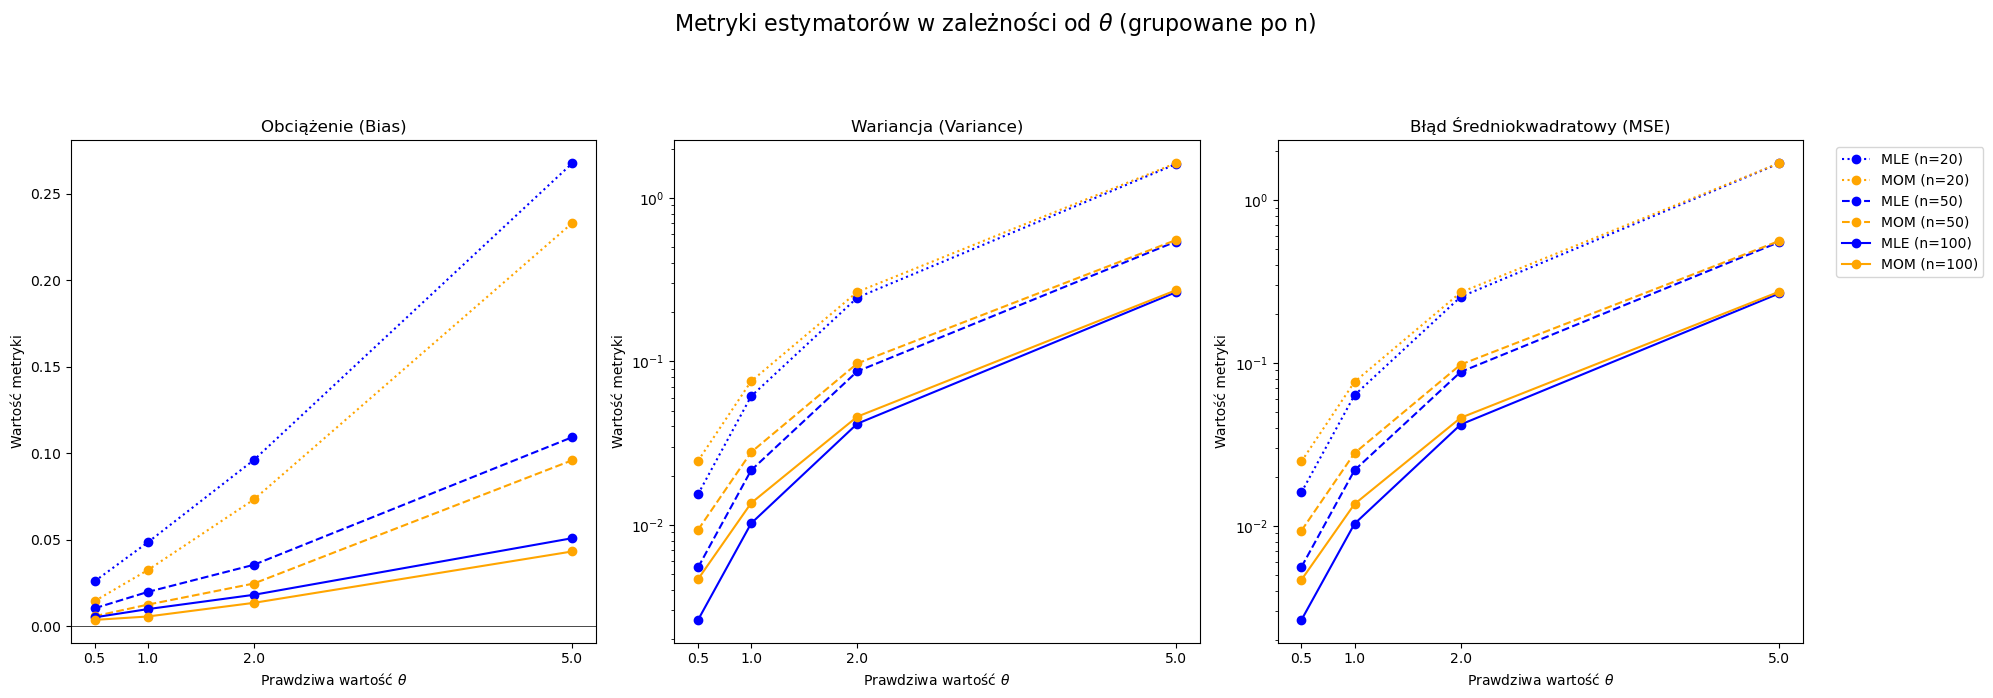

Zapisano wykres metryk vs. theta do: ../plots/zad4a/wykresy_metryk/metrics_vs_theta.png


In [ ]:
print("Generowanie wykresu 2: Metryki vs. theta...")
metric_names = ['bias', 'var', 'mse']
metric_titles = ['Obciążenie (Bias)', 'Wariancja (Variance)', 'Błąd Średniokwadratowy (MSE)']
colors = {'mle': 'blue', 'mom': 'orange'}
linestyles = {20: ':', 50: '--', 100: '-'}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Metryki estymatorów w zależności od $\\theta$ (grupowane po n)', fontsize=16, y=1.02)

for k, (metric_name, metric_title) in enumerate(zip(metric_names, metric_titles)):
    ax = axes[k]
    for n in ns:
        for est_name in ['mle', 'mom']:
            metric_values = [metrics[n][theta][est_name][metric_name] for theta in thetas]
            ax.plot(thetas, metric_values,
                    marker='o',
                    color=colors[est_name],
                    linestyle=linestyles[n],
                    label=f'{est_name.upper()} (n={n})')

    ax.set_title(metric_title)
    ax.set_xlabel('Prawdziwa wartość $\\theta$')
    ax.set_ylabel('Wartość metryki')
    ax.set_xticks(thetas)

    if metric_name == 'bias':
        ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
    else:
        ax.set_yscale('log')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

filename = os.path.join(plot_metrics_dir, 'metrics_vs_theta.png')
plt.savefig(filename)

plt.show()
plt.close()
print(f"Zapisano wykres metryk vs. theta do: {filename}")

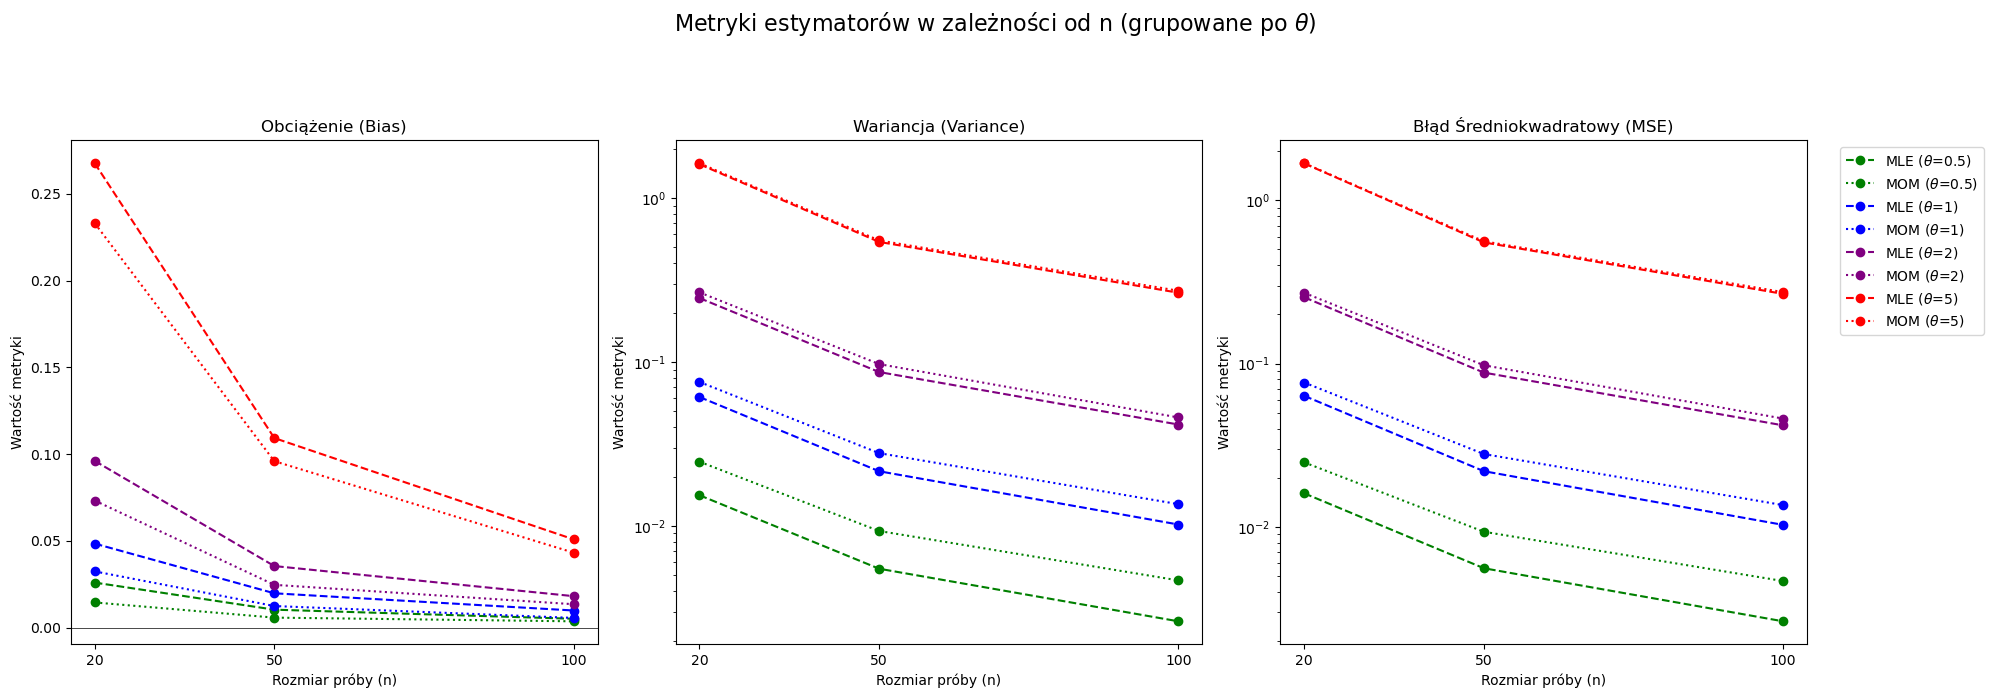

Zapisano wykres metryk vs. n do: ../plots/zad4a/wykresy_metryk/metrics_vs_n.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Metryki estymatorów w zależności od n (grupowane po $\\theta$)', fontsize=16, y=1.02)
colors = {0.5: 'green', 1: 'blue', 2: 'purple', 5: 'red'}
linestyles = {'mle': '--', 'mom': ':'}

for k, (metric_name, metric_title) in enumerate(zip(metric_names, metric_titles)):
    ax = axes[k]
    for theta in thetas:
        for est_name in ['mle', 'mom']:
            metric_values = [metrics[n][theta][est_name][metric_name] for n in ns]
            ax.plot(ns, metric_values,
                    marker='o',
                    color=colors[theta],
                    linestyle=linestyles[est_name],
                    label=f'{est_name.upper()} ($\\theta$={theta})')

    ax.set_title(metric_title)
    ax.set_xlabel('Rozmiar próby (n)')
    ax.set_ylabel('Wartość metryki')
    ax.set_xticks(ns)

    if metric_name == 'bias':
        ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
    else:
        ax.set_yscale('log')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

filename = os.path.join(plot_metrics_dir, 'metrics_vs_n.png')
plt.savefig(filename)

plt.show()
plt.close()
print(f"Zapisano wykres metryk vs. n do: {filename}")